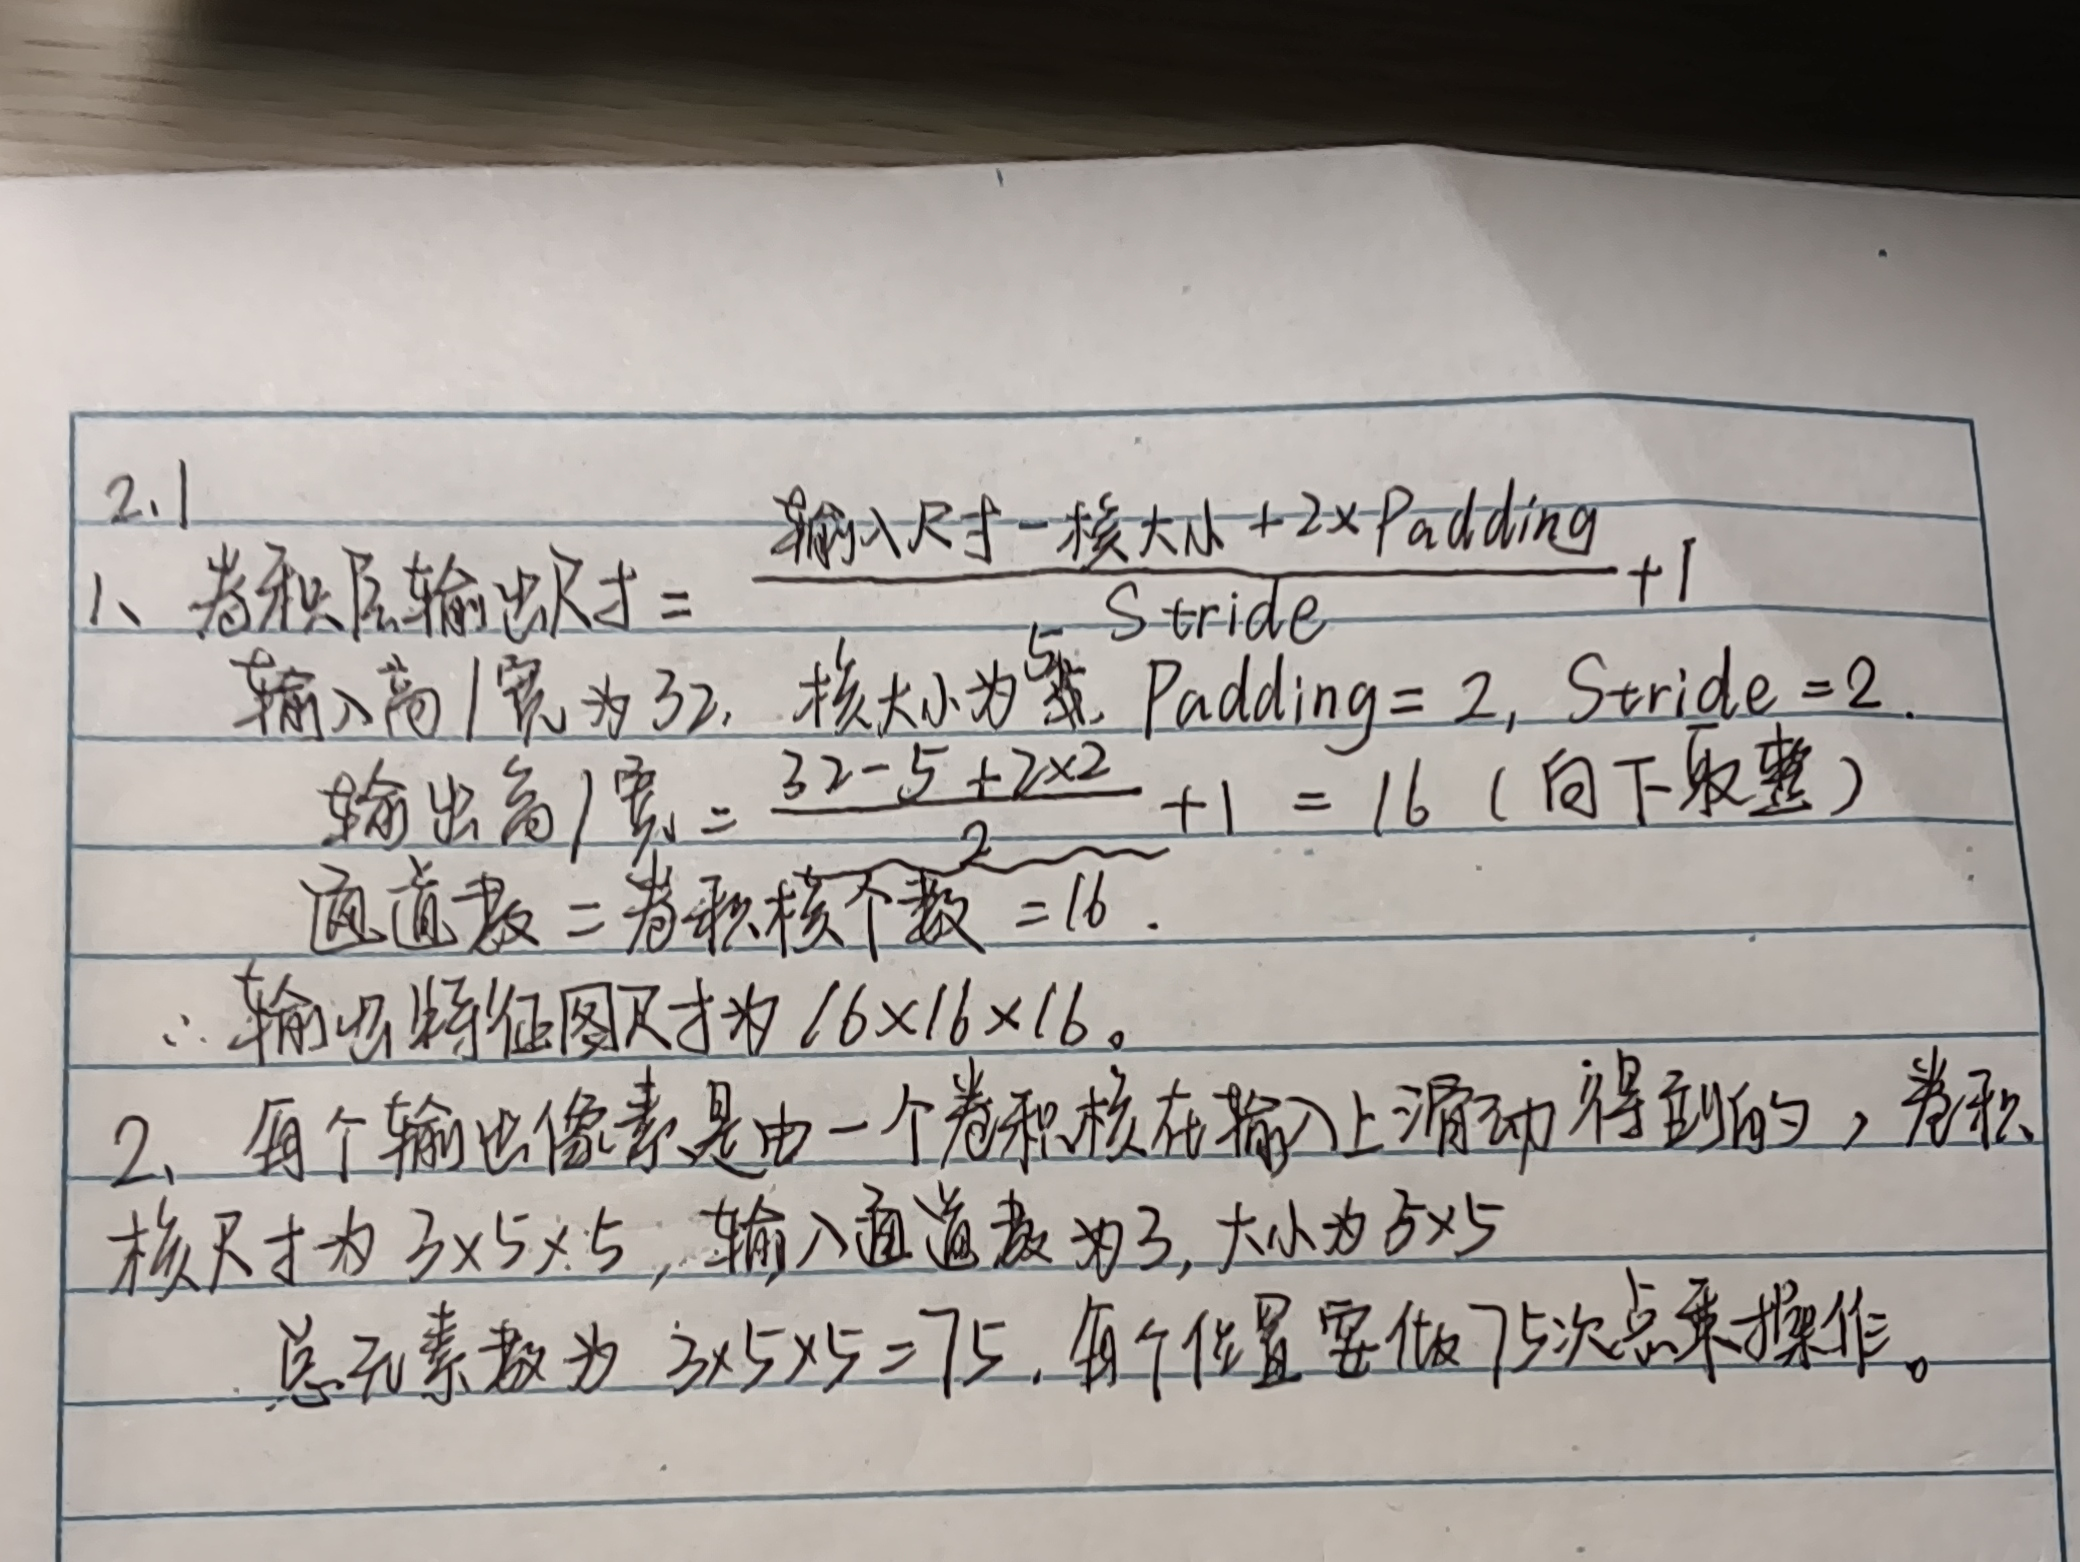

In [3]:
#2.2不使用深度学习框架的底层 Pooling API（如 ‘torch.nn.MaxPool2d‘），仅使用 Python 和 NumPy（或 PyTorch 基础张量操作），手动实现一个支持步幅（stride）和填充（padding）的二维最大池化（Max Pooling）前向传播数。
import numpy as np
def max_pooling_2d(x, kernel_size, stride=1, padding=0):
    """
    手动实现2D最大池化
    参数：x: 输入张量，形状 (N, C, H, W)
        kernel_size: 池化核大小（int或tuple）
        stride: 步幅
        padding: 填充
    返回：
        池化后的张量
    """
    # 处理输入
    if isinstance(kernel_size, int):
        k_h = k_w = kernel_size
    else:
        k_h, k_w = kernel_size
    
    N, C, H, W = x.shape
    # 计算输出尺寸
    out_h = (H + 2*padding - k_h) // stride + 1
    out_w = (W + 2*padding - k_w) // stride + 1
    
    # 填充输入
    if padding > 0:
        x_padded = np.pad(x, ((0,0), (0,0), (padding,padding), (padding,padding)), mode='constant')
    else:
        x_padded = x
    
    # 初始化输出为整数类型
    output = np.zeros((N, C, out_h, out_w), dtype=np.int32)
    
    # 执行池化
    for n in range(N):
        for c in range(C):
            for i in range(out_h):
                for j in range(out_w):
                    h_start = i * stride
                    w_start = j * stride
                    h_end = h_start + k_h
                    w_end = w_start + k_w
                    output[n, c, i, j] = np.max(x_padded[n, c, h_start:h_end, w_start:w_end])
    
    return output

# 测试代码
if __name__ == "__main__":
    # 创建测试数据 (batch=1, channel=1, height=4, width=4)
    test_input = np.array([[[[ 1,  2, 15,  3],
                             [ 4,  5, 15,  6],
                             [ 7,  8, 15, 19],
                             [10, 11, 15, 12]]]], dtype=np.int32)
    
    print("输入:")
    print(test_input[0,0])
    
    result = max_pooling_2d(test_input, kernel_size=2, stride=2)
    
    print("\n池化后:")
    print(result[0,0])

输入:
[[ 1  2 15  3]
 [ 4  5 15  6]
 [ 7  8 15 19]
 [10 11 15 12]]

池化后:
[[ 5 15]
 [11 19]]


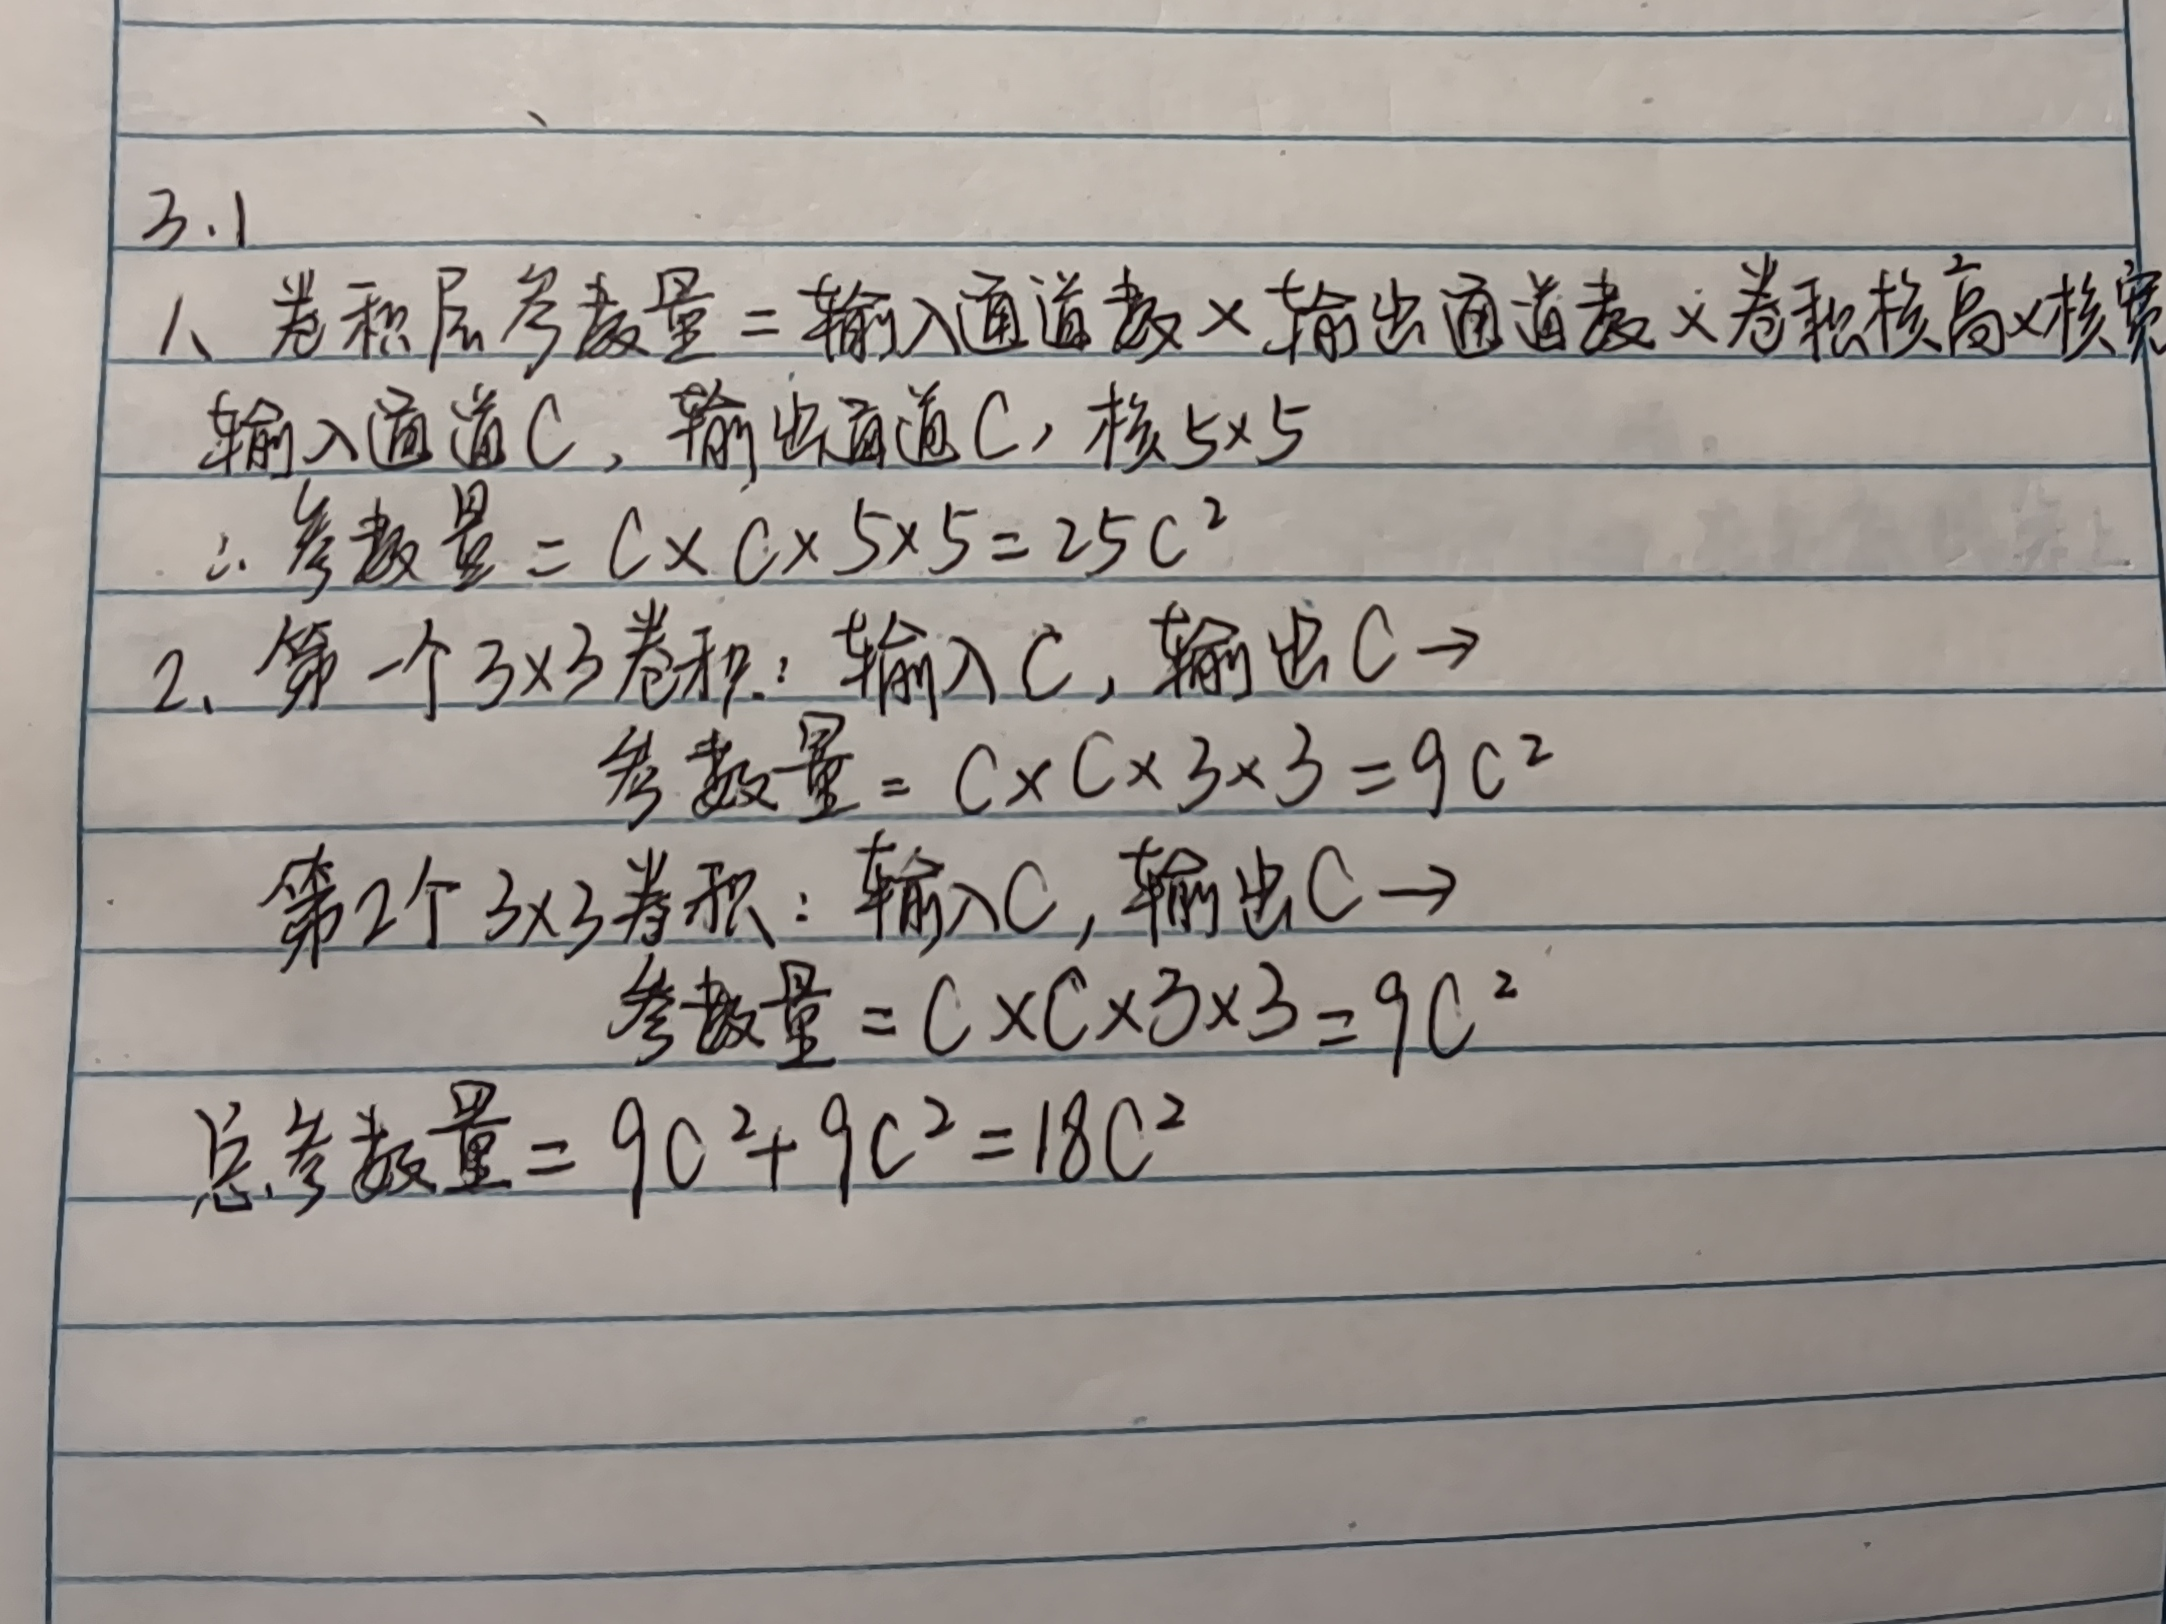

In [ ]:
#3.2NiN 网络的核心创新是引入了“1x1 卷积”组成的 NiN 块来代替传统的全连接层，以减少参数量。请使用 PyTorch（‘torch.nn.Sequential‘）定义一个标准的 NiN 块（NiN Block）。
#要求：NiN 块接收输入通道数 ‘in_channels‘ 和输出通道数 ‘out_channels‘，它由一个普通的卷积层（指定窗口大小 ‘kernel_size‘，步幅 ‘stride‘，填‘padding‘）以及两个随后的 1 × 1 卷积层级联组成。每层卷积后都需要紧跟一个 ReLU 激活层。
import torch
import torch.nn as nn
def nin_block(in_channels, out_channels, kernel_size, stride=1, padding=0):
    """
    NiN块普通卷积 + 两个1x1卷积，每个后接ReLU
    """
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),  # 1x1卷积
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),  # 1x1卷积
        nn.ReLU()
    )

# 测试代码
if __name__ == "__main__":
    block = nin_block(in_channels=3, out_channels=16, kernel_size=3, padding=1)
    print(block)
    # 测试输入
    test_input = torch.randn(1, 3, 32, 32)
    output = block(test_input)
    print(f"输出形状: {output.shape}")  #为 [1, 16, 32, 32]

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU()
  (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU()
)
输出形状: torch.Size([1, 16, 32, 32])


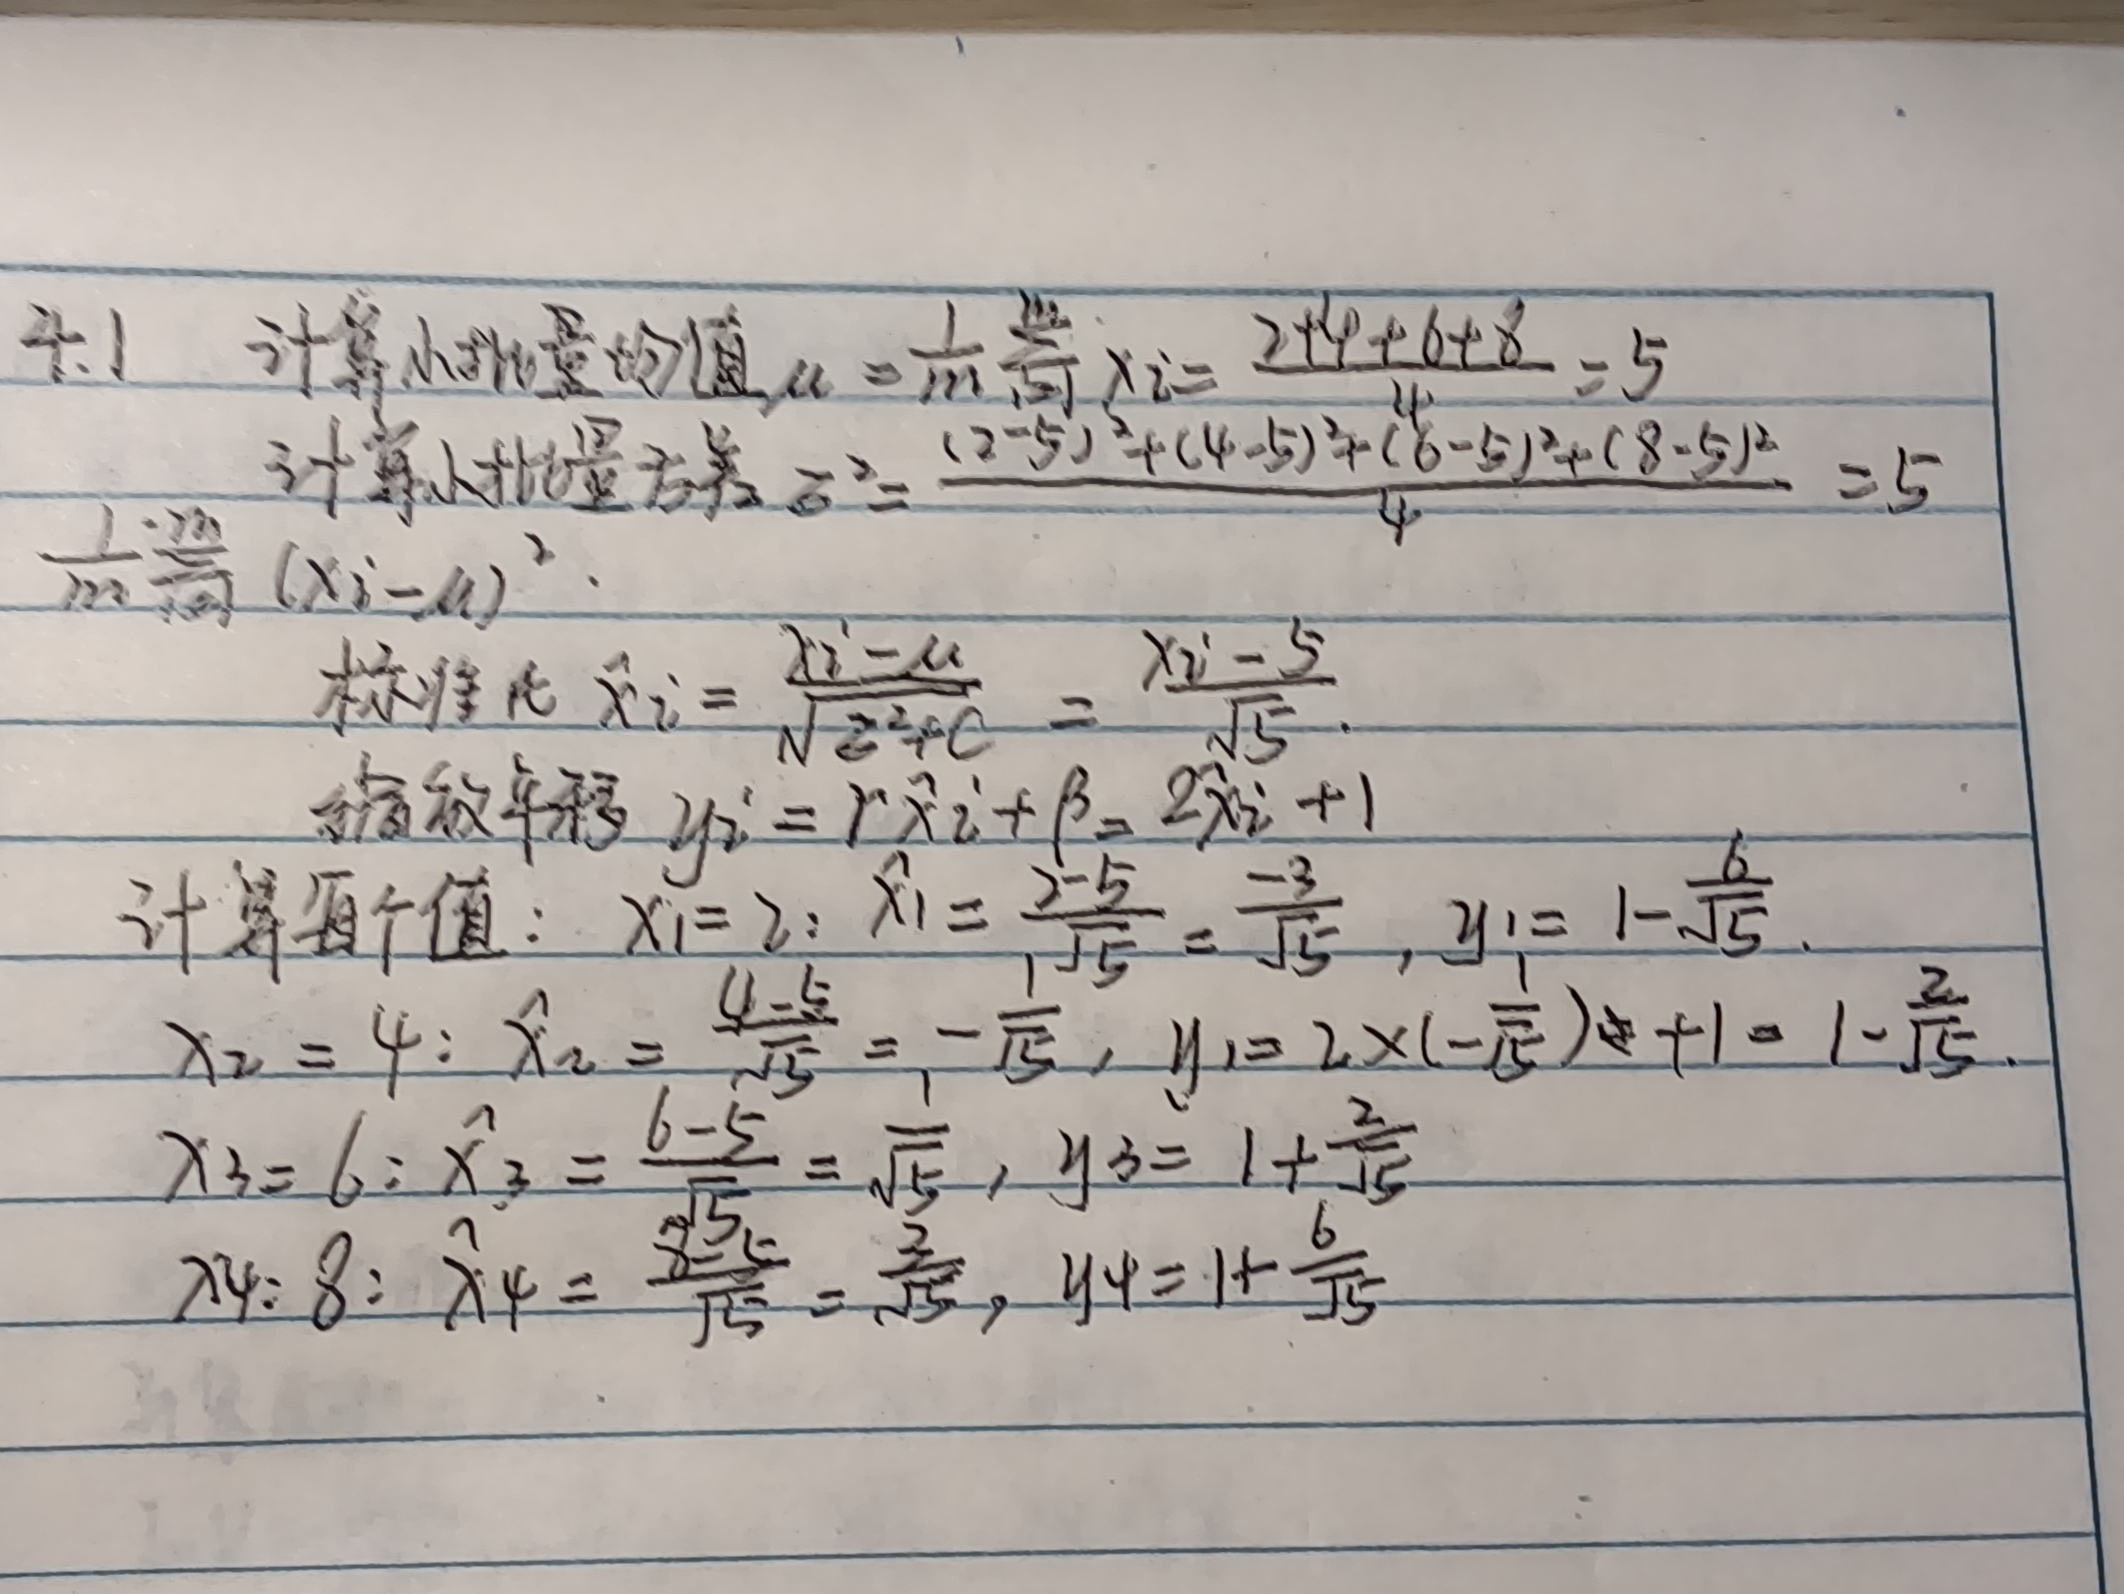

In [6]:
#4.2残差网络（ResNet）通过引入跨层连接（残差连接）解决了深层网络的梯度消失问题。请用 PyTorch 自定义一个残差块类 ‘Residual‘。
#要求：该块包含两个具有相同输出通道数的 3 × 3 卷积层，每个卷积层后跟一个批量归一化层。如果 ‘use_1x1conv=True‘，则需要对输入应用一个 1 × 1 的卷积层来调整输入的通道数和形状，以便它能和第二层卷积的输出进行按元素相加（f(x) + x）。
import torch
import torch.nn as nn
class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super().__init__()
        # 第一个3x3卷积 + BN
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                              padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # 第二个3x3卷积 + BN
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                              padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        # 1x1卷积调整通道和尺寸如果需要
        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels, out_channels, 
                                  kernel_size=1, stride=stride)
        else:
            self.conv3 = None
        self.relu = nn.ReLU()

    def forward(self, X):
        Y = self.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)  # 调整输入通道和尺寸
        Y += X  # 残差连接
        return self.relu(Y)

# 测试代码
if __name__ == "__main__":
    # 测试不带1x1卷积
    block1 = Residual(in_channels=16, out_channels=16)
    test_input = torch.randn(1, 16, 32, 32)
    output1 = block1(test_input)
    print(f"不带1x1卷积输出形状: {output1.shape}")
    
    # 测试带1x1卷积
    block2 = Residual(in_channels=16, out_channels=32, use_1x1conv=True, stride=2)
    output2 = block2(test_input)
    print(f"带1x1卷积输出形状: {output2.shape}")

不带1x1卷积输出形状: torch.Size([1, 16, 32, 32])
带1x1卷积输出形状: torch.Size([1, 32, 16, 16])


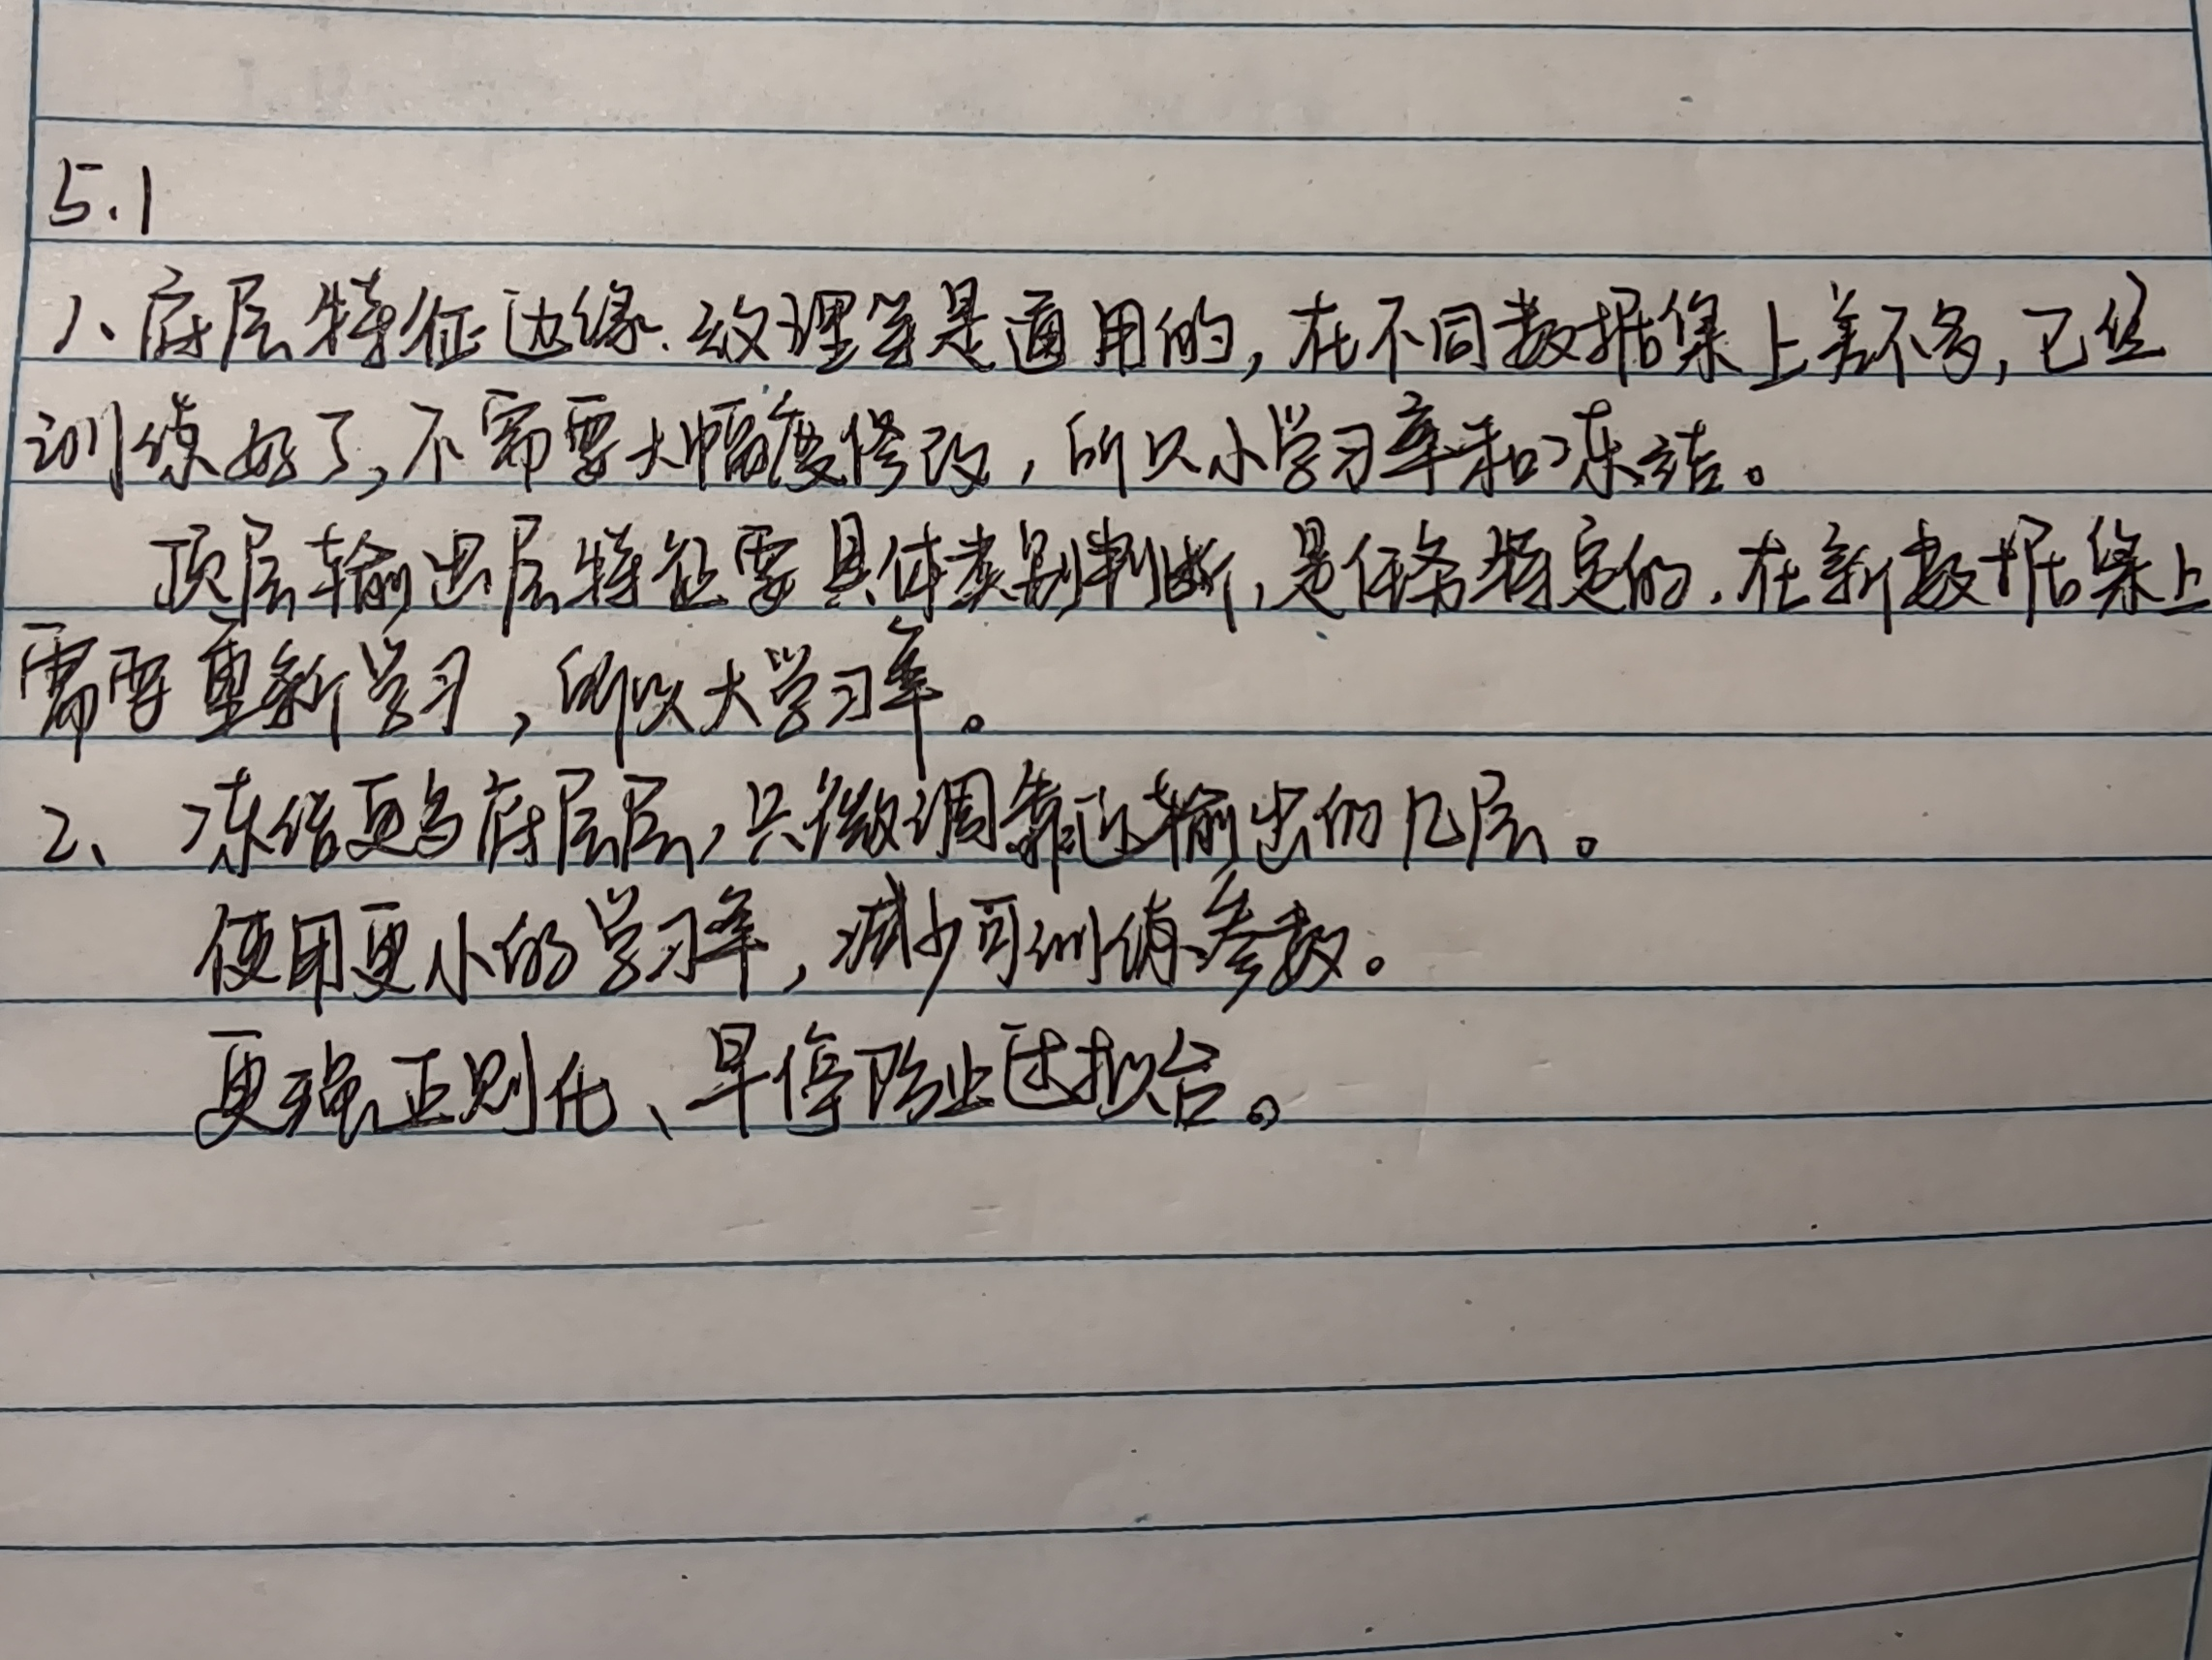

In [7]:
#5.2图像增广能有效增强模型的泛化能力。请利用 ‘torchvision.transforms‘模块创建一个组合图像增广管道（Pipeline）。
from torchvision import transforms
def get_augmentation_pipeline():
    """创建图像增广管道"""
    pipeline = transforms.Compose([
        #1.随机对图像进行裁剪，使其面积比例在 0.08 到 1.0 之间，并将裁剪后的图像缩放到 224 × 224 像素。
        transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
        #2.拥有 50% 的概率对图像进行水平翻转。
        transforms.RandomHorizontalFlip(p=0.5),
        #3.随机改变图像的亮度（Brightness）、对比度（Contrast）和饱和度（Saturation），变化范围设为 0.5。
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
        #4.最终将图像转换为 PyTorch 张量（Tensor）。
        transforms.ToTensor()
    ])
    return pipeline

# 测试代码
if __name__ == "__main__":
    aug_pipe = get_augmentation_pipeline()
    print("增广管道:", aug_pipe)
    # 实际使用时：augmented_img = aug_pipe(original_img)

增广管道: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.5, 1.5), hue=None)
    ToTensor()
)


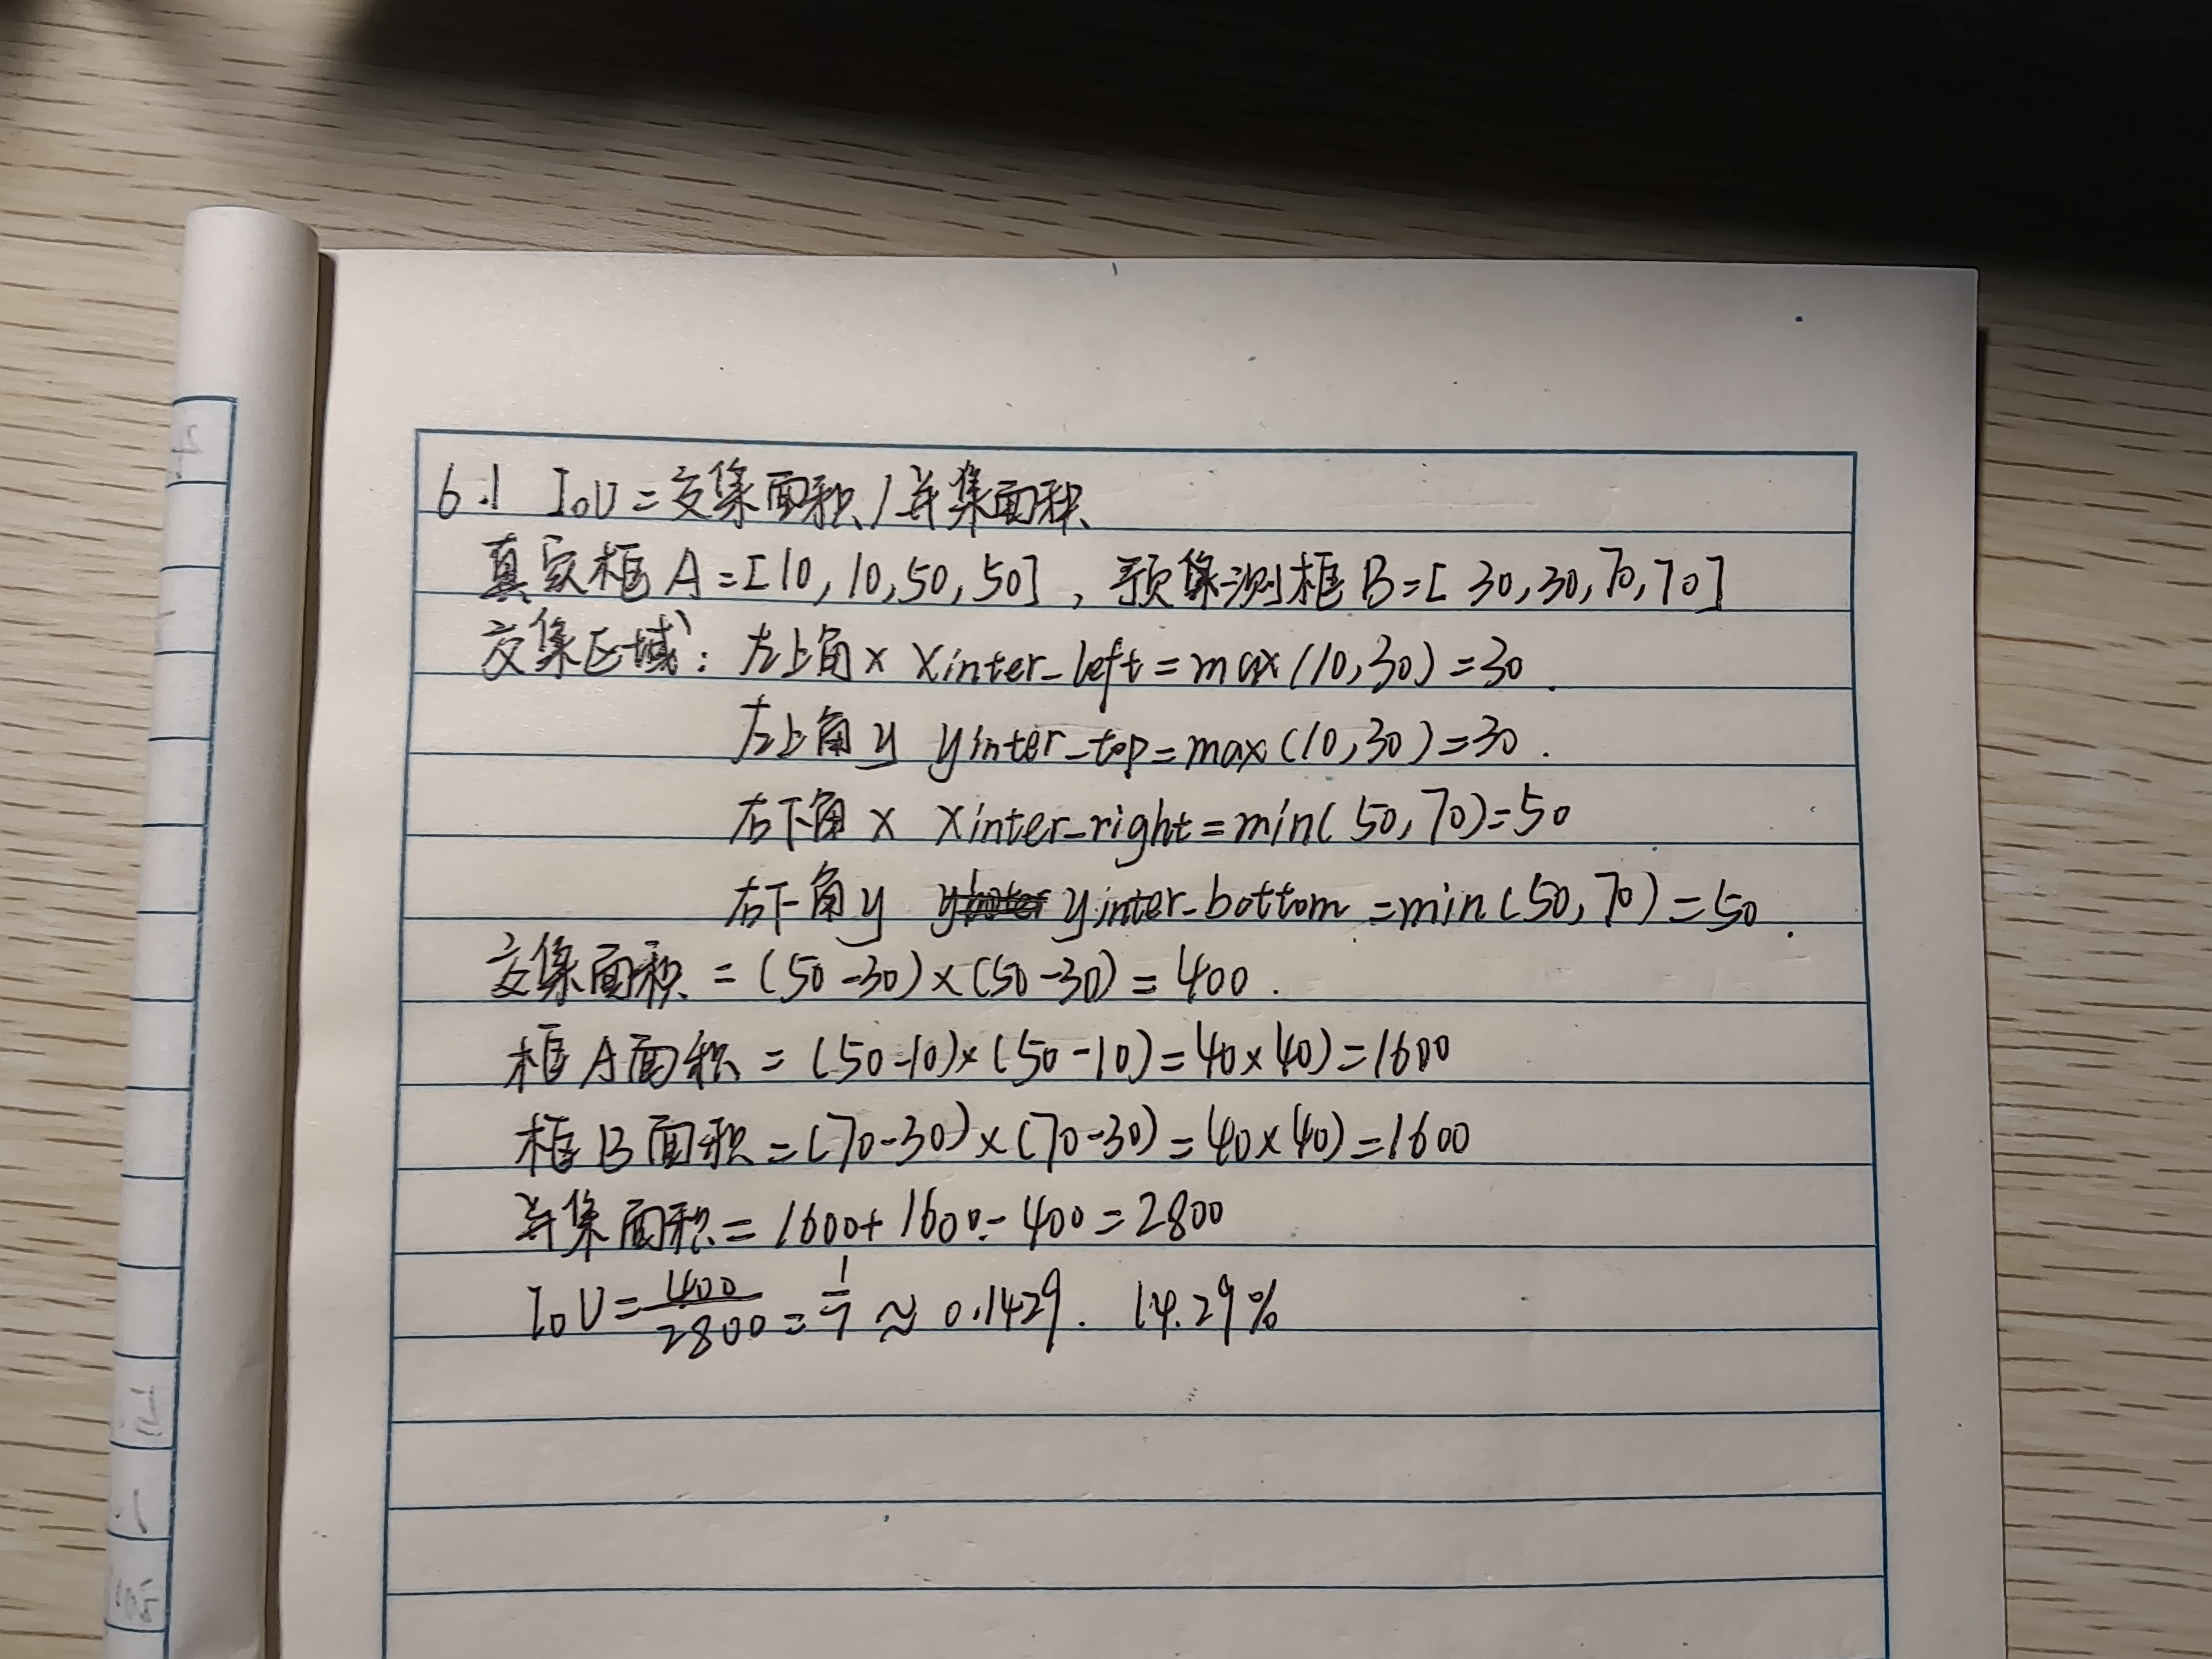

In [8]:
#6.2在计算机视觉训练技巧中，标签平滑（Label Smoothing）通过防止模型过于自信地预测某些类别来提高泛化性。标准交叉熵使用独热编码（One-hot），若设置平滑因子 ϵ = 0.1，则对于 K 分类问题，真实标签对应的目标概率从 1 变为 1 − ϵ，其余错误类别的概率从 0 变为 Kϵ−1。
#请实现一个计算标签平滑后交叉熵损失的函数
import torch
import torch.nn as nn
def label_smoothing_cross_entropy(pred, target, epsilon=0.1, reduction='mean'):
    """
    标签平滑交叉熵损失
    参数：
        pred: 模型输出logits，形状 (N, K)
        target: 真实标签索引，形状 (N,)
        epsilon: 平滑因子
        reduction: 'mean'或'sum'
    """
    K = pred.size(1)  # 类别数
    # 计算softmax
    log_probs = torch.log_softmax(pred, dim=1)
    # 创建平滑后的标签分布
    smooth_target = torch.zeros_like(pred)
    smooth_target.fill_(epsilon / (K - 1))  # 非目标类概率
    smooth_target.scatter_(1, target.unsqueeze(1), 1 - epsilon)  # 目标类概率
    # 计算损失
    loss = -torch.sum(smooth_target * log_probs, dim=1)
    if reduction == 'mean':
        return loss.mean()
    elif reduction == 'sum':
        return loss.sum()
    else:
        return loss

# 测试代码
if __name__ == "__main__":
    # 模拟数据
    pred = torch.tensor([[2.0, 1.0, 0.1], [0.5, 3.0, 0.2]])  # 2个样本，3个类别
    target = torch.tensor([0, 1])  # 第一个样本真实类别0，第二个类别1
    loss = label_smoothing_cross_entropy(pred, target, epsilon=0.1)
    print(f"标签平滑损失: {loss.item():.4f}")
    
    # 对比普通交叉熵
    ce_loss = nn.CrossEntropyLoss()(pred, target)
    print(f"普通交叉熵损失: {ce_loss.item():.4f}")

标签平滑损失: 0.4803
普通交叉熵损失: 0.2753
